/tmp/ipykernel_1909/2097956337.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x="Category", y="Total Amount", ax=axes[0, 0], palette="Blues_d")
/tmp/ipykernel_1909/2097956337.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="City", y="Orders", ax=axes[1, 1], palette="Greens_d")


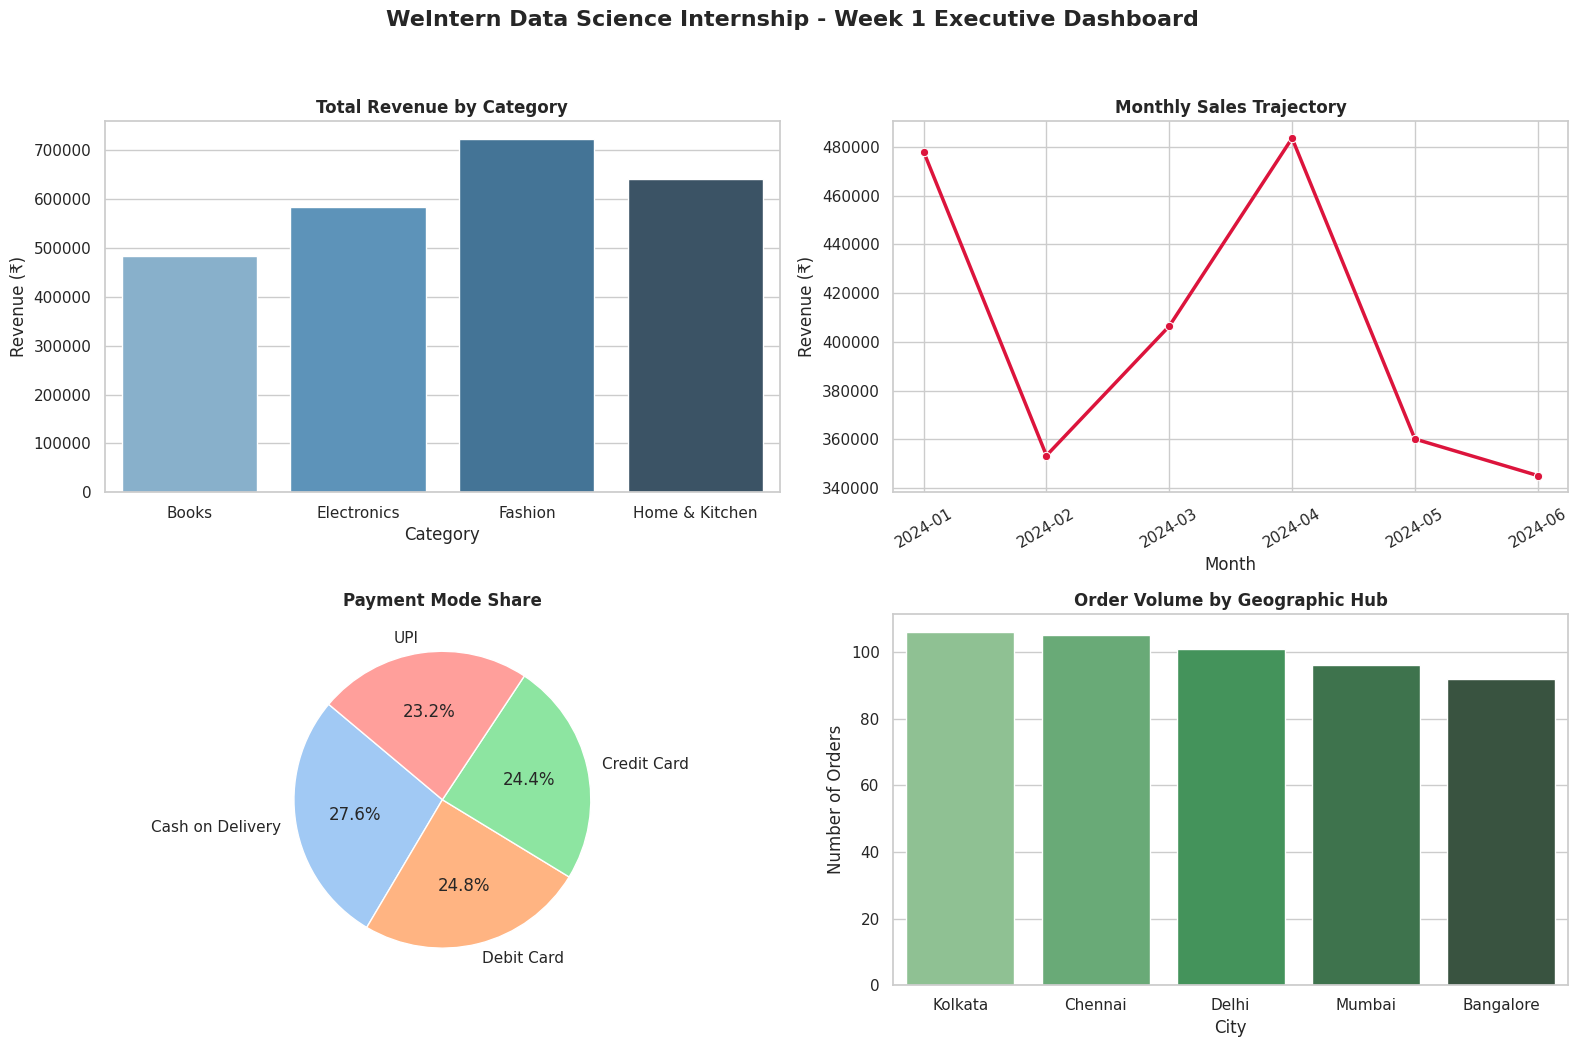

Charts generated and task3_sales_dashboard.png saved successfully!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Simulation
np.random.seed(42)
n_rows = 500
dates = pd.date_range("2024-01-01", periods=180)
categories = ["Electronics", "Fashion", "Home & Kitchen", "Books"]
cities = ["Delhi", "Mumbai", "Bangalore", "Kolkata", "Chennai"]
payments = ["Credit Card", "UPI", "Debit Card", "Cash on Delivery"]

df = pd.DataFrame({
    "Order ID": [f"ORD_{1000 + i}" for i in range(n_rows)],
    "Customer ID": [f"CUST_{np.random.randint(100, 180)}" for _ in range(n_rows)],
    "Category": np.random.choice(categories, n_rows),
    "Quantity": np.random.choice([1, 2, 3, 4], n_rows, p=[0.6, 0.25, 0.1, 0.05]),
    "Unit Price": np.random.choice([500, 1200, 2500, 15000], n_rows, p=[0.35, 0.3, 0.2, 0.15]),
    "Order Date": np.random.choice(dates, n_rows),
    "Payment Mode": np.random.choice(payments, n_rows),
    "Delivery Status": np.random.choice(["Delivered", "Cancelled", "Returned", "Pending"], n_rows),
    "City": np.random.choice(cities, n_rows),
})

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Total Amount"] = df["Quantity"] * df["Unit Price"]
df["Month"] = df["Order Date"].dt.strftime("%Y-%m")

# Set visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("WeIntern Data Science Internship - Week 1 Executive Dashboard", fontsize=16, fontweight="bold")

# Chart 1: Revenue by Category (Bar Chart)
cat_rev = df.groupby("Category")["Total Amount"].sum().reset_index()
sns.barplot(data=cat_rev, x="Category", y="Total Amount", ax=axes[0, 0], palette="Blues_d")
axes[0, 0].set_title("Total Revenue by Category", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Revenue (₹)")

# Chart 2: Monthly Sales Trend (Line Chart)
monthly_rev = df.groupby("Month")["Total Amount"].sum().reset_index()
sns.lineplot(data=monthly_rev, x="Month", y="Total Amount", marker="o", ax=axes[0, 1], color="crimson", linewidth=2.5)
axes[0, 1].set_title("Monthly Sales Trajectory", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Revenue (₹)")
axes[0, 1].tick_params(axis="x", rotation=30)

# Chart 3: Payment Mode Distribution (Pie Chart)
pay_counts = df["Payment Mode"].value_counts()
axes[1, 0].pie(pay_counts, labels=pay_counts.index, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
axes[1, 0].set_title("Payment Mode Share", fontsize=12, fontweight="bold")

# Chart 4: City-wise Order Volume (Bar Chart)
city_counts = df["City"].value_counts().reset_index()
city_counts.columns = ["City", "Orders"]
sns.barplot(data=city_counts, x="City", y="Orders", ax=axes[1, 1], palette="Greens_d")
axes[1, 1].set_title("Order Volume by Geographic Hub", fontsize=12, fontweight="bold")
axes[1, 1].set_ylabel("Number of Orders")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("task3_sales_dashboard.png", dpi=300)
plt.show()
print("Charts generated and task3_sales_dashboard.png saved successfully!")